### Customer Churn Prediction using Machine Learning

##### Step 1: Import Required Libraries

In [29]:
# ==========================
# Import Required Libraries
# ==========================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Save Model
import joblib

### Step 2: Load the Dataset

In [30]:
# Load Dataset
df = pd.read_csv("customerChurnDataset.csv")

# Display first 5 rows
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [31]:
# Drop CustomerID because it is just a unique identifier

df.drop("CustomerID", axis=1, inplace=True)

print("CustomerID column removed successfully.")

CustomerID column removed successfully.


In [32]:
# Shape of Dataset
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 64374
Columns : 11


In [33]:
# Display Column Names
df.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Churn'],
      dtype='str')

In [34]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Age                64374 non-null  int64
 1   Gender             64374 non-null  str  
 2   Tenure             64374 non-null  int64
 3   Usage Frequency    64374 non-null  int64
 4   Support Calls      64374 non-null  int64
 5   Payment Delay      64374 non-null  int64
 6   Subscription Type  64374 non-null  str  
 7   Contract Length    64374 non-null  str  
 8   Total Spend        64374 non-null  int64
 9   Last Interaction   64374 non-null  int64
 10  Churn              64374 non-null  int64
dtypes: int64(8), str(3)
memory usage: 6.6 MB


In [35]:
# Statistical Summary
df.describe()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [36]:
# Check Missing Values
df.isnull().sum()

Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [37]:
# Check Duplicate Records
df.duplicated().sum()

0

### Step 3: Exploratory Data Analysis (EDA)

EDA helps us understand the dataset, identify patterns, detect anomalies, and gain insights before building the machine learning model.

In [38]:
print(df.dtypes)

Age                  int64
Gender                 str
Tenure               int64
Usage Frequency      int64
Support Calls        int64
Payment Delay        int64
Subscription Type      str
Contract Length        str
Total Spend          int64
Last Interaction     int64
Churn                int64
dtype: object


In [39]:
for column in df.columns:
    print(f"\n{column}")
    print(df[column].unique())


Age
[22 41 47 35 53 30 54 36 65 46 56 31 42 59 29 45 62 48 55 64 25 44 28 34
 24 27 61 57 37 51 18 23 60 40 26 52 43 19 58 33 20 39 32 38 21 63 49 50]

Gender
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

Tenure
[25 28 27  9 58 41 37 36 20  8 42 13  2 46 21  1 54 40 39 50 59 60 44 23
 26 31 30 51 45 19 14 24 15 47  3 17 22 57 34 29 33 35 56  5 55 48  6 32
 16 10  7 43 52 53 38  4 11 18 49 12]

Usage Frequency
[14 28 10 12 24 15 11  5  4 27 23  7 17  3 30  2 19 20 18  8  6 21 26 16
 25 13 29  9 22  1]

Support Calls
[ 4  7  2  5  9 10  0  6  1  3  8]

Payment Delay
[27 13 29 17  2 10 28 18  8 23 21 14 25  3  6 15  1  9 30  4  0 11 16  7
 24 22 12 26 20 19  5]

Subscription Type
<ArrowStringArray>
['Basic', 'Standard', 'Premium']
Length: 3, dtype: str

Contract Length
<ArrowStringArray>
['Monthly', 'Annual', 'Quarterly']
Length: 3, dtype: str

Total Spend
[ 598  584  757  232  533  500  574  323  687  995  526  187  758  438
  663  677  636  127  396  202  925  463  449  

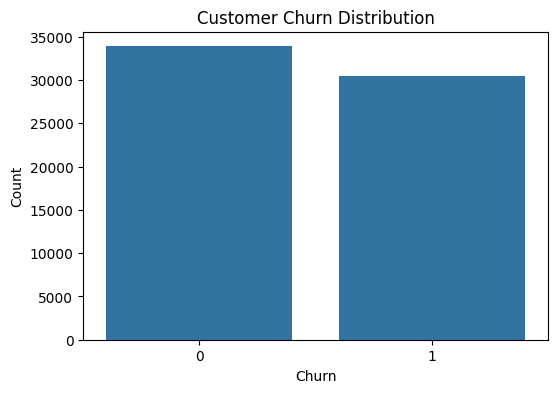

In [40]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

In [41]:
churn_percentage = df['Churn'].value_counts(normalize=True) * 100

print(churn_percentage)

Churn
0    52.631497
1    47.368503
Name: proportion, dtype: float64


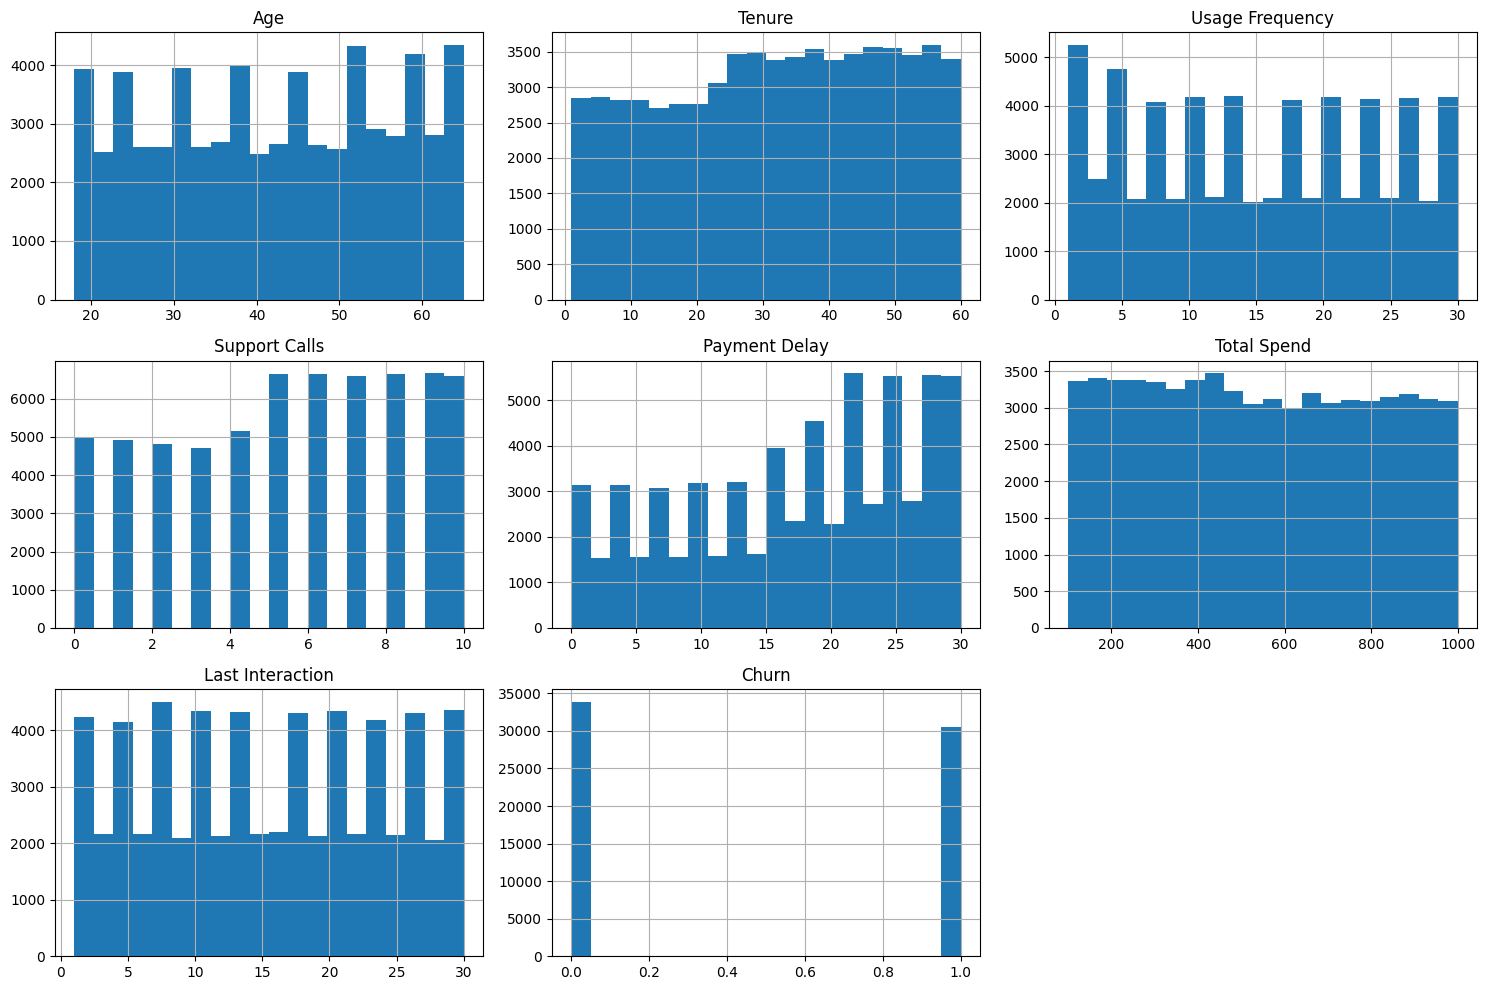

In [42]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns

df[numerical_columns].hist(figsize=(15,10), bins=20)

plt.tight_layout()

plt.show()

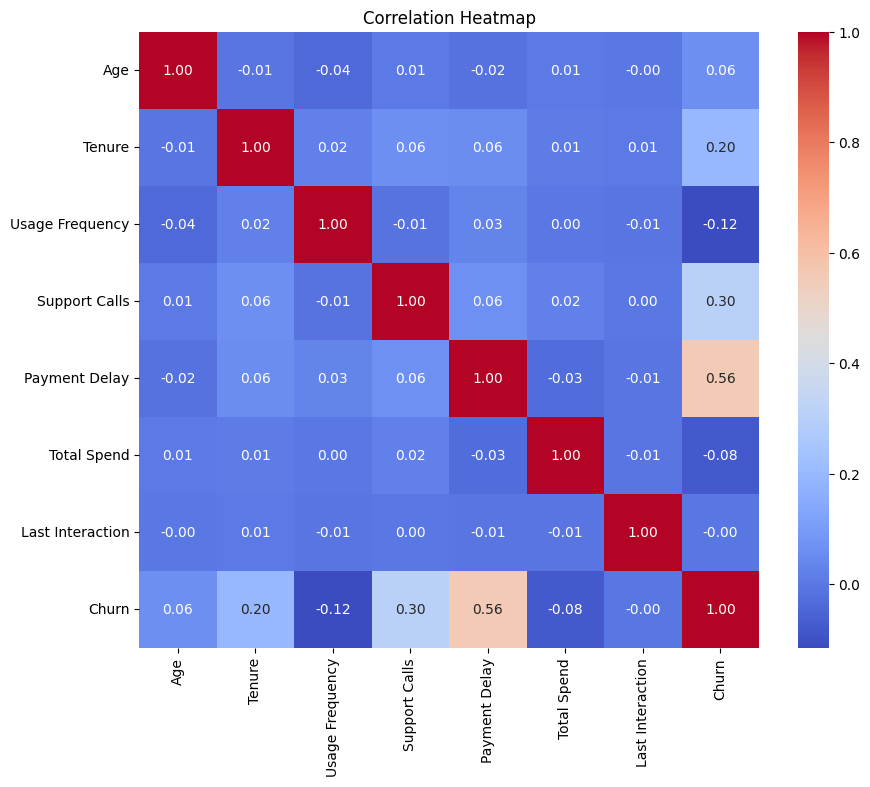

In [43]:
plt.figure(figsize=(10,8))

sns.heatmap(df[numerical_columns].corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap")

plt.show()

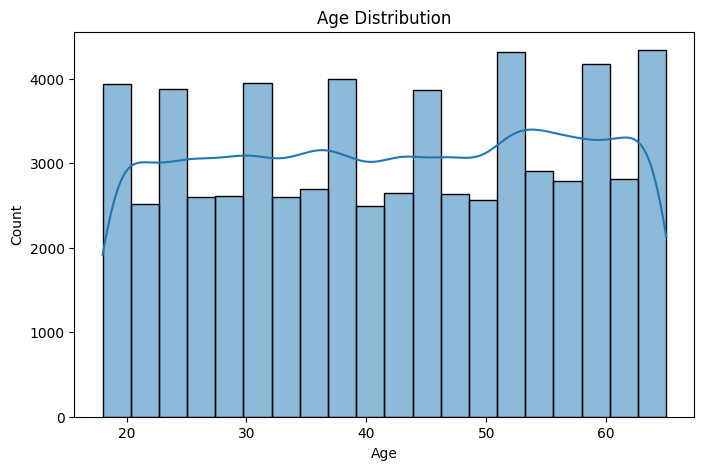

In [44]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Age Distribution")

plt.show()

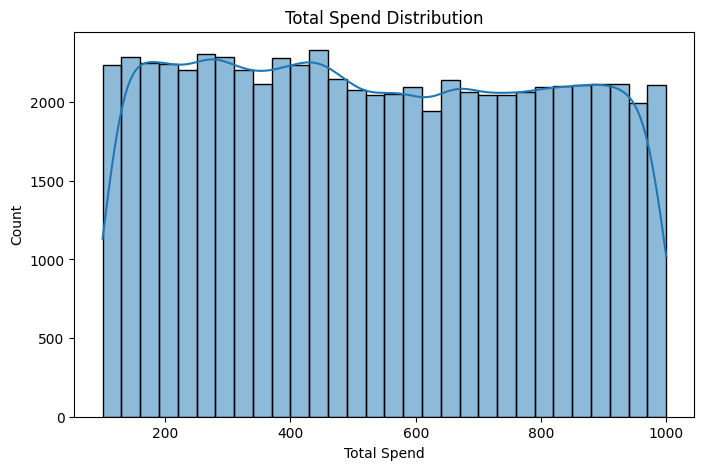

In [45]:
plt.figure(figsize=(8,5))

sns.histplot(df['Total Spend'], bins=30, kde=True)

plt.title("Total Spend Distribution")

plt.show()

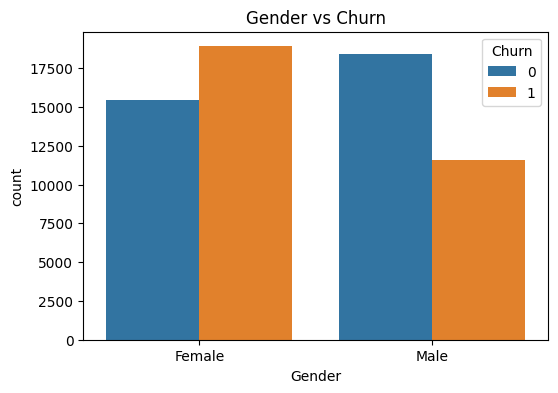

In [46]:
plt.figure(figsize=(6,4))

sns.countplot(x='Gender',
              hue='Churn',
              data=df)

plt.title("Gender vs Churn")

plt.show()

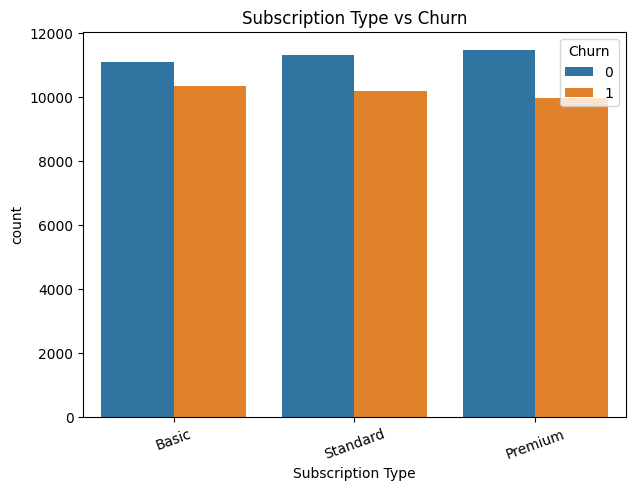

In [47]:
plt.figure(figsize=(7,5))

sns.countplot(x='Subscription Type',
              hue='Churn',
              data=df)

plt.title("Subscription Type vs Churn")

plt.xticks(rotation=20)

plt.show()

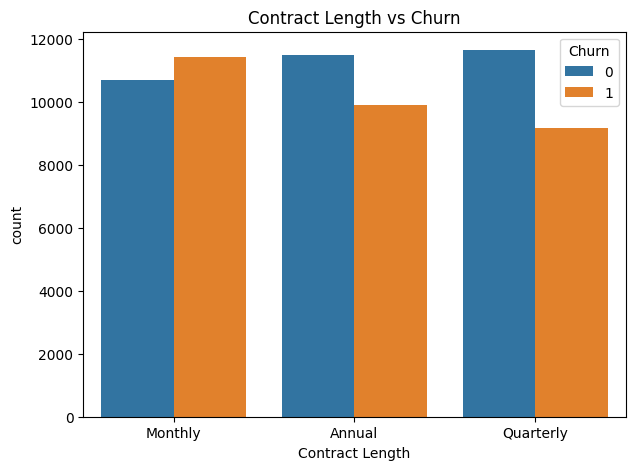

In [48]:
plt.figure(figsize=(7,5))

sns.countplot(x='Contract Length',
              hue='Churn',
              data=df)

plt.title("Contract Length vs Churn")

plt.show()

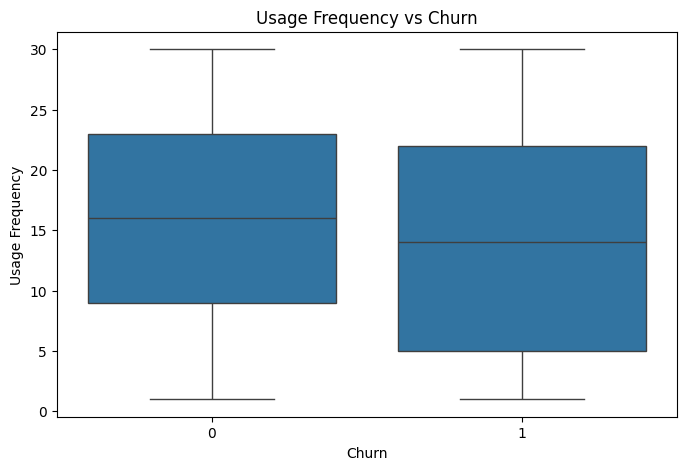

In [49]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn',
            y='Usage Frequency',
            data=df)

plt.title("Usage Frequency vs Churn")

plt.show()

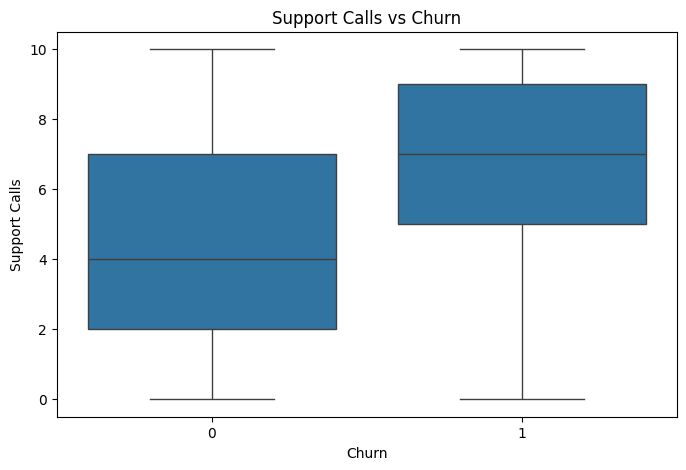

In [50]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn',
            y='Support Calls',
            data=df)

plt.title("Support Calls vs Churn")

plt.show()

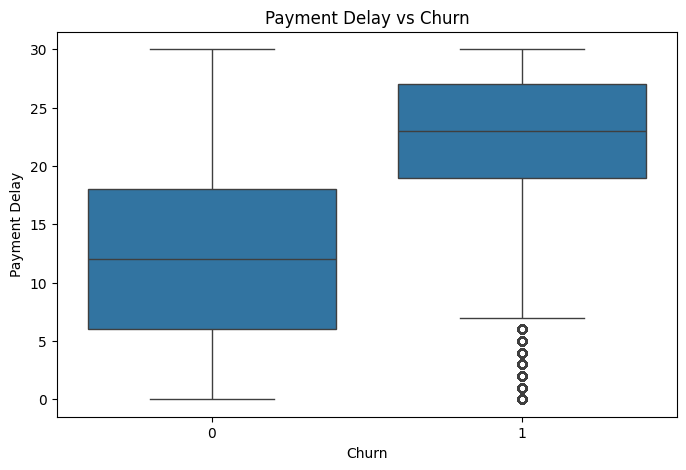

In [51]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn',
            y='Payment Delay',
            data=df)

plt.title("Payment Delay vs Churn")

plt.show()

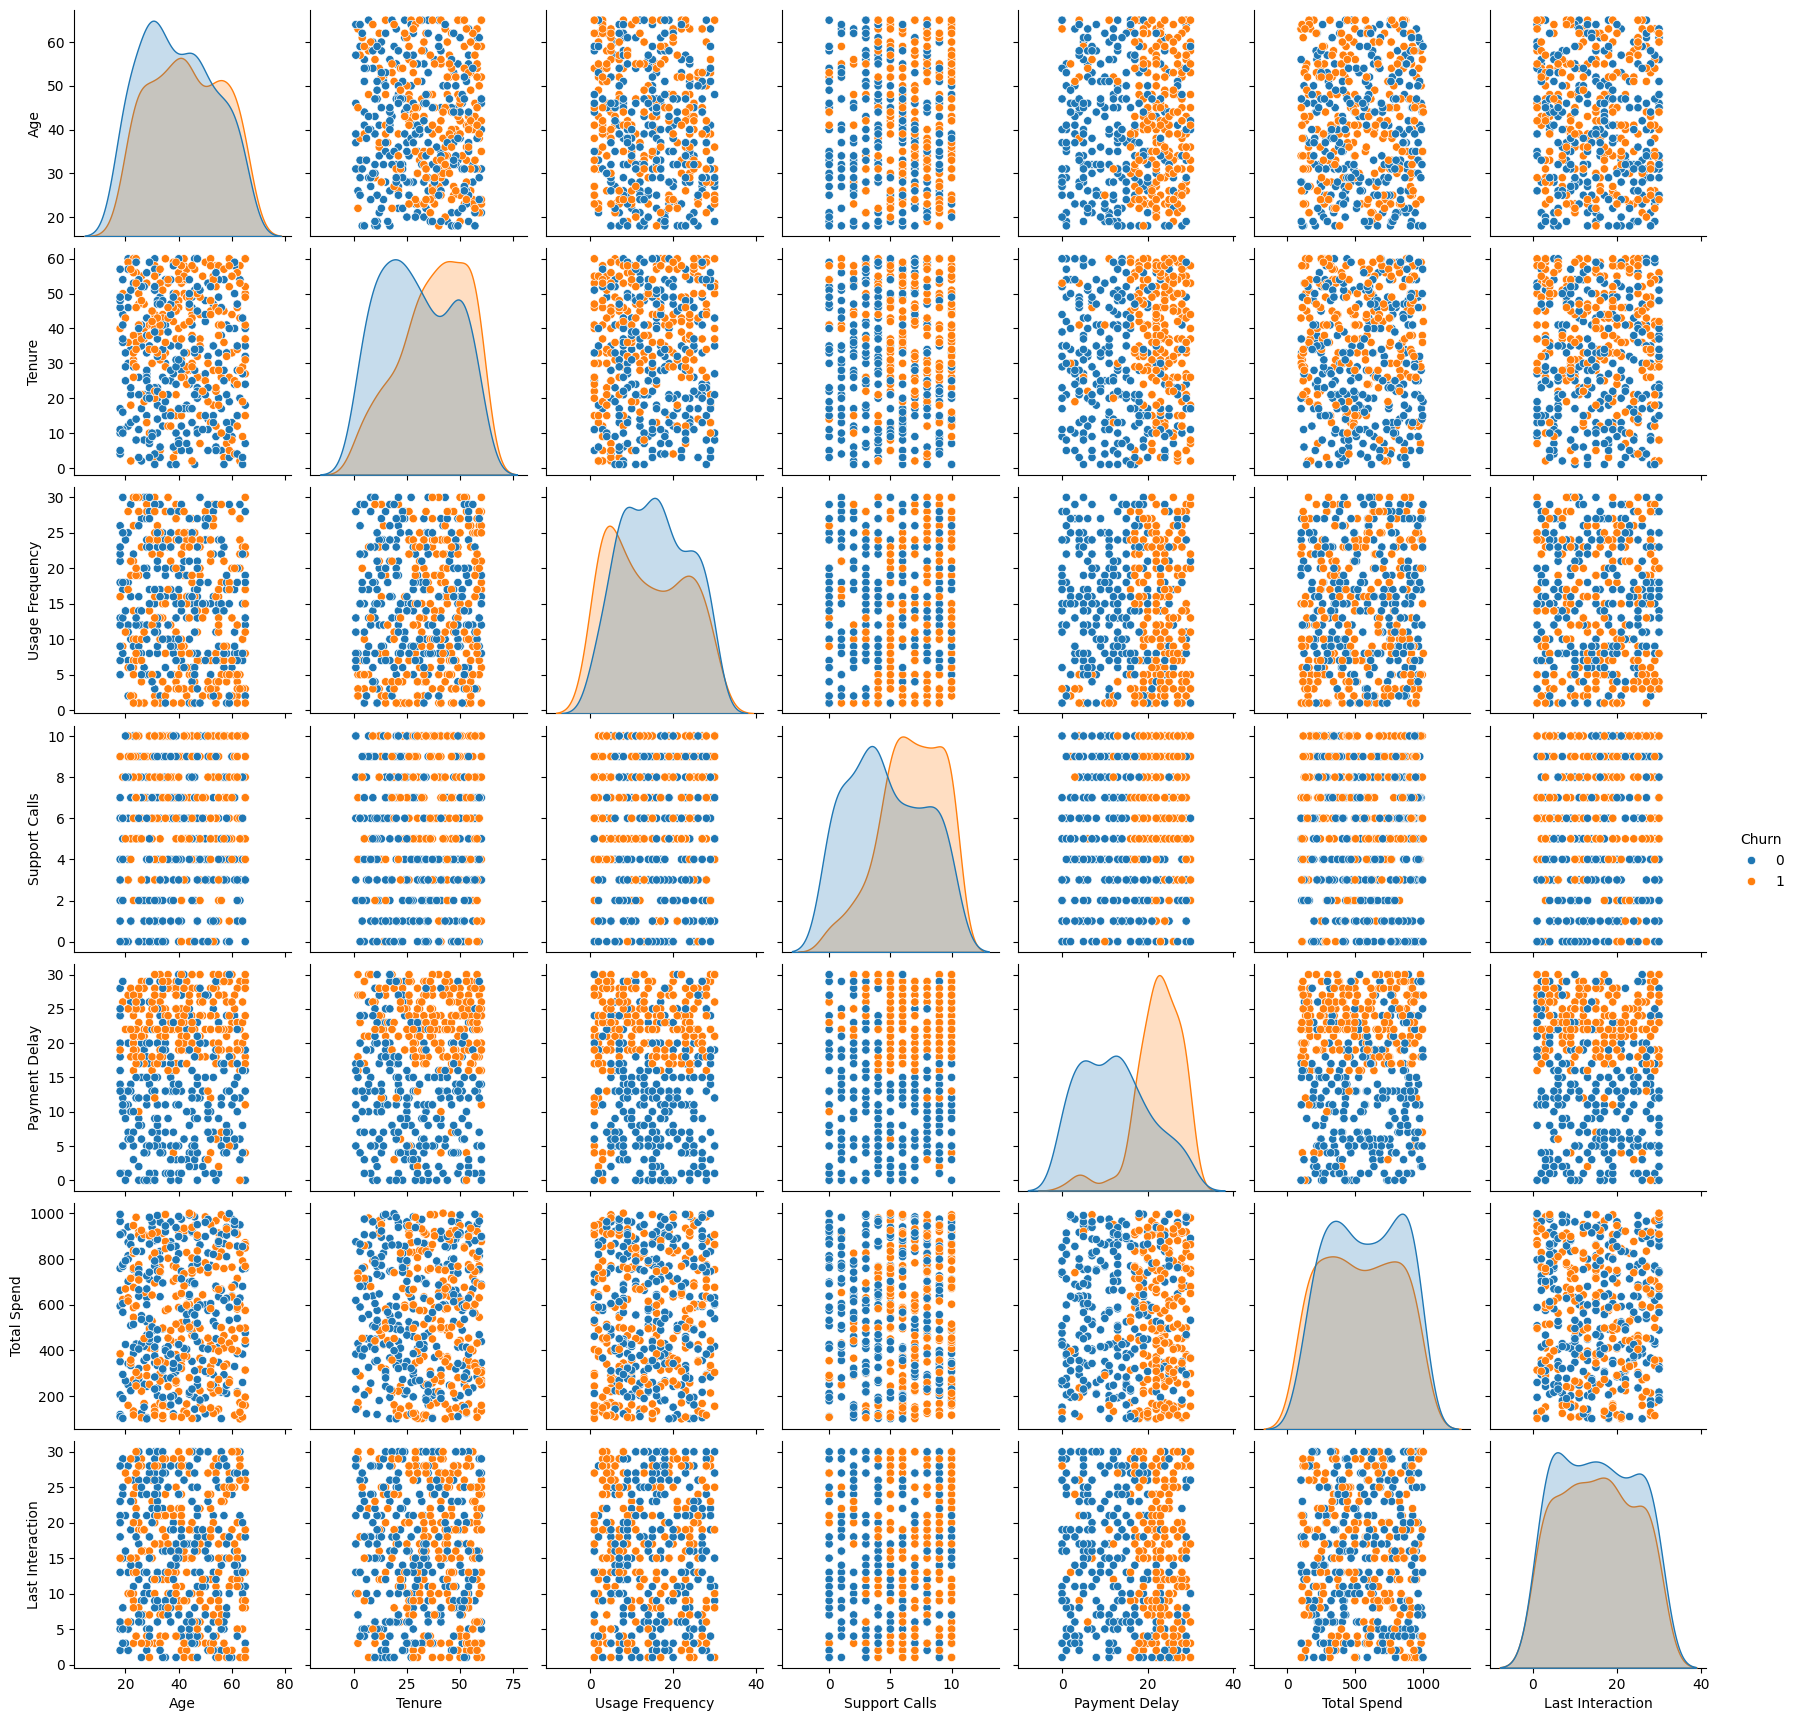

In [52]:
sample_df = df.sample(500, random_state=42)

sns.pairplot(sample_df,
             hue='Churn')

plt.show()

## Insights from EDA

1. There are no missing values in the dataset.

2. There are no duplicate records.

3. The target variable distribution was checked to understand class balance.

4. Numerical feature distributions were visualized.

5. Correlation analysis was performed using a heatmap.

6. Customer churn was analyzed across Gender, Subscription Type, and Contract Length.

7. Boxplots were used to understand how Usage Frequency, Support Calls, and Payment Delay differ between churned and retained customers.

## Outlier Detection

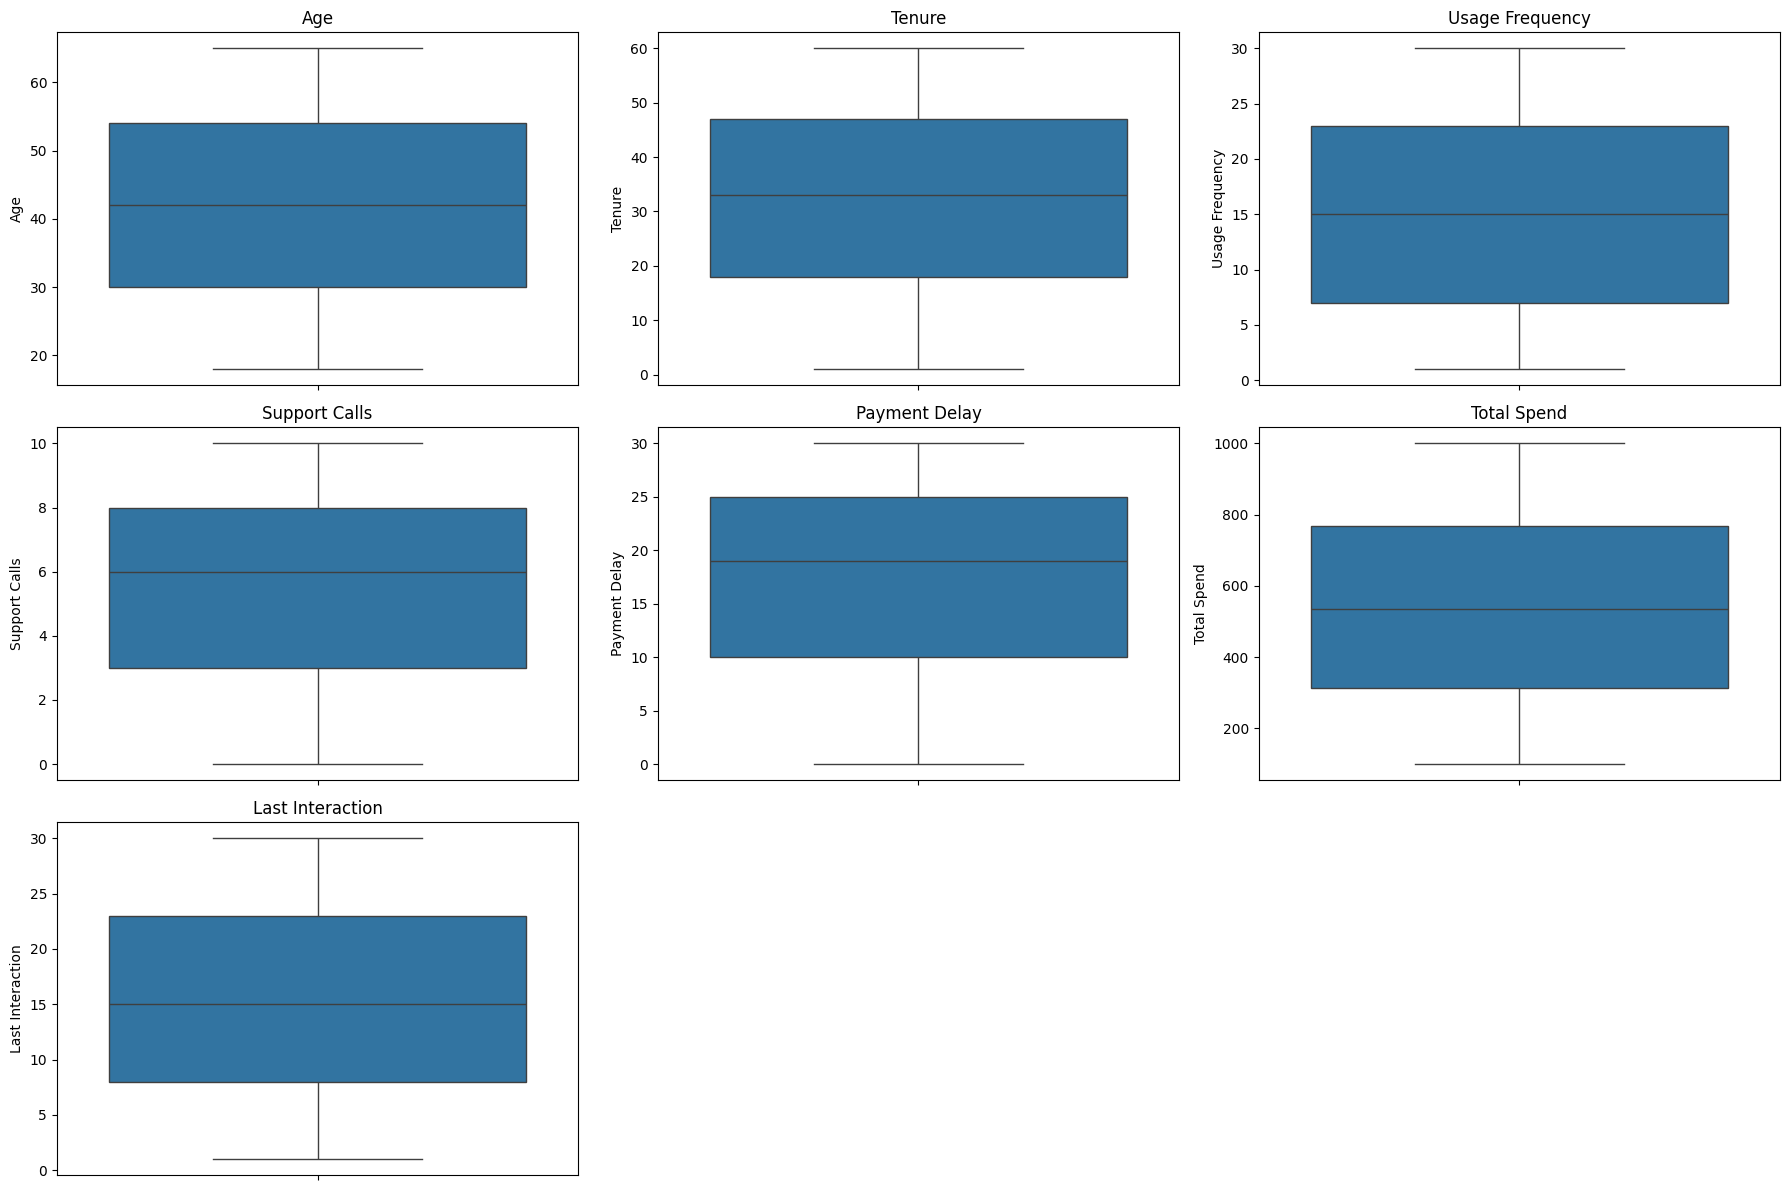

In [53]:
numerical_columns = [
    'Age',
    'Tenure',
    'Usage Frequency',
    'Support Calls',
    'Payment Delay',
    'Total Spend',
    'Last Interaction'
]

plt.figure(figsize=(18,12))

for i, col in enumerate(numerical_columns):
    plt.subplot(3,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()

plt.show()

# Step 4: Data Preprocessing

Data preprocessing is the process of preparing raw data before training the machine learning model.

The preprocessing steps include:

- Removing unnecessary columns
- Separating features and target variable
- Encoding categorical variables
- Splitting the dataset into training and testing sets
- Feature Scaling

In [54]:
df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,53,Female,58,24,9,2,Standard,Annual,533,18,0


## Separating Features and Target Variable

X contains all independent variables.

y contains the dependent variable (Customer Churn).

In [55]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (64374, 10)
Shape of y: (64374,)


In [56]:
categorical_columns = X.select_dtypes(include="object").columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['Gender', 'Subscription Type', 'Contract Length'], dtype='str')


In [57]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for column in categorical_columns:
    
    le = LabelEncoder()
    
    X[column] = le.fit_transform(X[column])
    
    label_encoders[column] = le

In [58]:
X.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
0,22,0,25,14,4,27,0,1,598,9
1,41,0,28,28,7,13,2,1,584,20
2,47,1,27,10,2,29,1,0,757,21
3,35,1,9,12,5,17,1,2,232,18
4,53,0,58,24,9,2,2,0,533,18


In [59]:
joblib.dump(label_encoders, "label_encoders.pkl")

print("Label Encoders Saved Successfully")

Label Encoders Saved Successfully


## Train-Test Split

The dataset is divided into training and testing sets.

Training Data : 80%

Testing Data : 20%

Random State = 42 for reproducibility.

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [61]:
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features : (51499, 10)
Testing Features : (12875, 10)
Training Labels : (51499,)
Testing Labels : (12875,)


## Feature Scaling

Feature Scaling ensures that numerical features are on the same scale.

This improves the performance of distance-based and gradient-based machine learning algorithms.

In [74]:
from sklearn.preprocessing import StandardScaler

# Create StandardScaler Object
scaler = StandardScaler()

# Scale Training and Testing Data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert NumPy Arrays back to DataFrames
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

# Display Scaled Training Data
print(X_train_scaled.head())

# Save the Scaler
joblib.dump(scaler, "scaler.pkl")

print("Scaler Saved Successfully")

            Age    Gender    Tenure  Usage Frequency  Support Calls  \
13468  1.007489 -0.934617  0.586916        -0.461726      -1.733835   
20118  0.864009  1.069957  1.639129        -1.142305      -0.770040   
48411 -0.786001  1.069957 -1.166770        -1.482595       1.157549   
42125 -0.642522 -0.934617 -0.582208         0.218853      -0.127510   
55119 -0.212084 -0.934617 -0.231471         1.693442      -1.091305   

       Payment Delay  Subscription Type  Contract Length  Total Spend  \
13468      -0.805979           0.000713         1.252748     0.968288   
20118      -0.918834           1.224401         1.252748     0.266576   
48411      -1.144543          -1.222975        -1.219528    -1.221206   
42125       0.886844           0.000713         0.016610     0.412287   
55119       0.886844           0.000713         0.016610     1.696841   

       Last Interaction  
13468         -0.057826  
20118          0.984556  
48411          1.679478  
42125          0.521275  
5511

## Conclusion

The dataset has been successfully preprocessed.

The following steps were completed:


- Features and target separated
- Categorical variables encoded
- Dataset split into training and testing sets
- Feature scaling performed
- Label encoders and scaler saved for deployment

# Step 5: Model Building and Evaluation

In this section, multiple machine learning algorithms are trained and evaluated.

The performance of each model is compared using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score

The best-performing model will be selected for deployment.

In [75]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

In [77]:
!pip install xgboost


[notice] A new release of pip is available: 23.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [78]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}

In [79]:
results = []

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc
    ])

In [80]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.830602,0.814141,0.831141,0.822553,0.830630
1,Decision Tree,0.998835,0.998849,0.998685,0.998767,0.998827
2,Random Forest,0.999456,0.999835,0.999013,0.999424,0.999433
3,KNN,0.910214,0.881269,0.936041,0.907830,0.911565
4,XGBoost,0.999922,0.999836,1.000000,0.999918,0.999926


In [81]:
results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,XGBoost,0.999922,0.999836,1.000000,0.999918,0.999926
2,Random Forest,0.999456,0.999835,0.999013,0.999424,0.999433
1,Decision Tree,0.998835,0.998849,0.998685,0.998767,0.998827
3,KNN,0.910214,0.881269,0.936041,0.907830,0.911565
0,Logistic Regression,0.830602,0.814141,0.831141,0.822553,0.830630


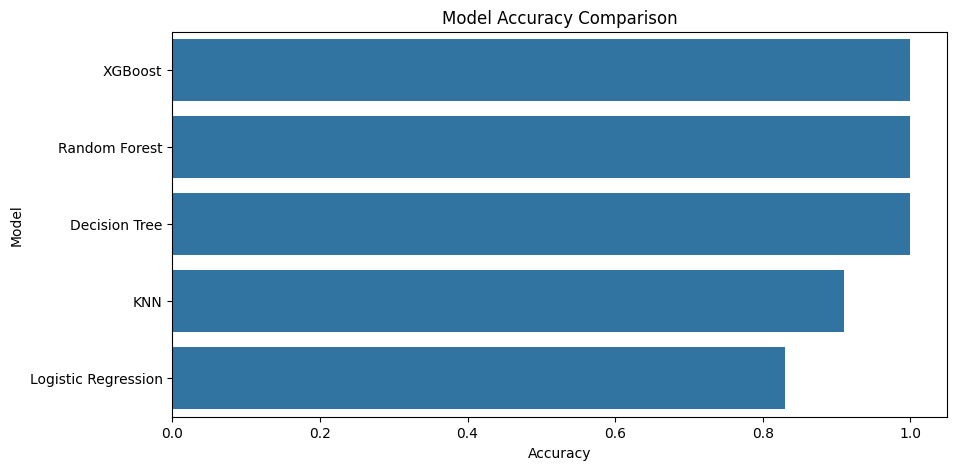

In [82]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Accuracy",
    y="Model",
    data=results_df
)

plt.title("Model Accuracy Comparison")

plt.show()

In [83]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model :", best_model_name)

Best Model : XGBoost


In [89]:
# Save the name of the best model
print(f"Best Model Selected: {best_model_name}")

# Train the best model again (optional but explicit)
best_model.fit(X_train_scaled, y_train)

Best Model Selected: XGBoost


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [90]:
best_model = models[best_model_name]

joblib.dump(best_model, "model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [85]:
loaded_model = joblib.load("model.pkl")

print("Model Loaded Successfully")

Model Loaded Successfully


## Conclusion

Five machine learning models were trained and evaluated.

The models were compared using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score

The best-performing model was selected and saved for deployment.

In [86]:
correlation = df.corr(numeric_only=True)["Churn"].sort_values(ascending=False)

print(correlation)

Churn               1.000000
Payment Delay       0.557386
Support Calls       0.304631
Tenure              0.195327
Age                 0.063457
Last Interaction   -0.002818
Total Spend        -0.078867
Usage Frequency    -0.115098
Name: Churn, dtype: float64


In [87]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

Age: 48
Gender: 2
Tenure: 60
Usage Frequency: 30
Support Calls: 11
Payment Delay: 31
Subscription Type: 3
Contract Length: 3
Total Spend: 901
Last Interaction: 30
Churn: 2


In [88]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

             Feature  Importance
5      Payment Delay    0.436948
4      Support Calls    0.156691
2             Tenure    0.110662
3    Usage Frequency    0.088038
1             Gender    0.075394
7    Contract Length    0.041771
8        Total Spend    0.041748
0                Age    0.038913
9   Last Interaction    0.006685
6  Subscription Type    0.003150


# Step 6: Advanced Model Evaluation

In this section, the selected machine learning model is evaluated using advanced techniques to better understand its performance.

The following evaluation methods are used:

- Confusion Matrix
- Classification Report
- ROC Curve
- Feature Importance

In [92]:
# Predict using the best model
y_pred = best_model.predict(X_test_scaled)

# Prediction probabilities
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

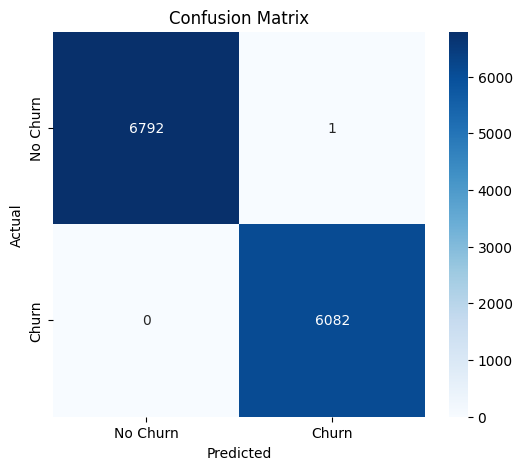

In [93]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [94]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6793
           1       1.00      1.00      1.00      6082

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



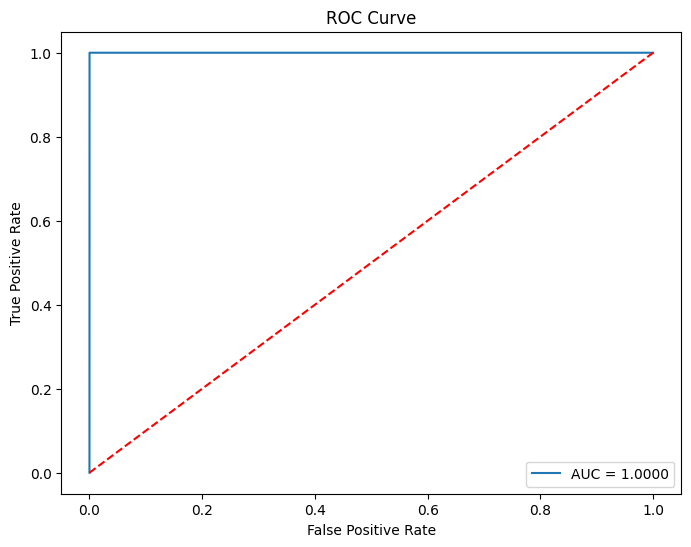

In [95]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [96]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
5,Payment Delay,0.396713
1,Gender,0.193580
4,Support Calls,0.146460
3,Usage Frequency,0.063409
2,Tenure,0.059599
0,Age,0.055970
7,Contract Length,0.041627
8,Total Spend,0.036705
6,Subscription Type,0.005761
9,Last Interaction,0.000177


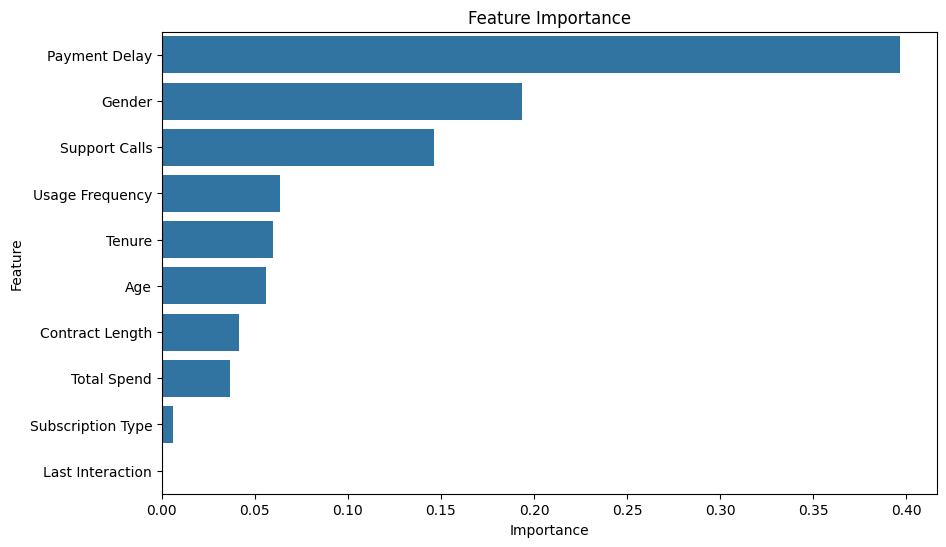

In [97]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.show()

In [98]:
joblib.dump(best_model, "model.pkl")

print("Final model saved successfully!")

Final model saved successfully!


## Conclusion

The XGBoost model achieved the best performance among all evaluated models.

The model was further validated using:

- Confusion Matrix
- Classification Report
- ROC Curve
- Feature Importance

The trained model has been saved successfully and is ready for deployment.

In [ ]:
!pip install shap

In [100]:
joblib.dump(best_model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")

['label_encoders.pkl']

In [101]:
import os

os.makedirs("models", exist_ok=True)

joblib.dump(best_model, "models/model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(label_encoders, "models/label_encoders.pkl")

print("All files saved successfully.")

All files saved successfully.


In [102]:
feature_names = X_train.columns.tolist()

joblib.dump(feature_names, "models/feature_names.pkl")

print("Feature names saved successfully.")

Feature names saved successfully.
